In [39]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

First we construct the data we will be working on, which is a specific version of the lorentz system determined by our choice of parameters. This time series data will be used to train and then also test our model.

In [40]:
# Lorenz system functions

def lorenz_deriv(state, t, sigma, rho, beta):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]


def generate_lorenz_data(x0=1, y0=1, z0=1, sigma=10, rho=28, beta=8/3, dt=0.01, t_max=100):
    t = np.arange(0, t_max, dt)
    n = len(t)
    x = np.zeros(n)
    y = np.zeros(n)
    z = np.zeros(n)
    x[0], y[0], z[0] = x0, y0, z0
    for i in range(n-1):
        state = [x[i], y[i], z[i]]
        k1 = lorenz_deriv(state, t[i], sigma, rho, beta)
        k2 = lorenz_deriv([x[i] + 0.5*dt*k1[0], y[i] + 0.5*dt*k1[1], z[i] + 0.5*dt*k1[2]], t[i] + 0.5*dt, sigma, rho, beta)
        k3 = lorenz_deriv([x[i] + 0.5*dt*k2[0], y[i] + 0.5*dt*k2[1], z[i] + 0.5*dt*k2[2]], t[i] + 0.5*dt, sigma, rho, beta)
        k4 = lorenz_deriv([x[i] + dt*k3[0], y[i] + dt*k3[1], z[i] + dt*k3[2]], t[i] + dt, sigma, rho, beta)
        x[i+1] = x[i] + (dt/6) * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
        y[i+1] = y[i] + (dt/6) * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
        z[i+1] = z[i] + (dt/6) * (k1[2] + 2*k2[2] + 2*k3[2] + k4[2])
    return t, x, y, z


def plot_lorenz(t, x, y, z):
    fig = plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(t, x)
    plt.title('x vs time')
    plt.subplot(1, 3, 2)
    plt.plot(t, y)
    plt.title('y vs time')
    plt.subplot(1, 3, 3)
    plt.plot(t, z)
    plt.title('z vs time')
    plt.tight_layout()
    plt.show()

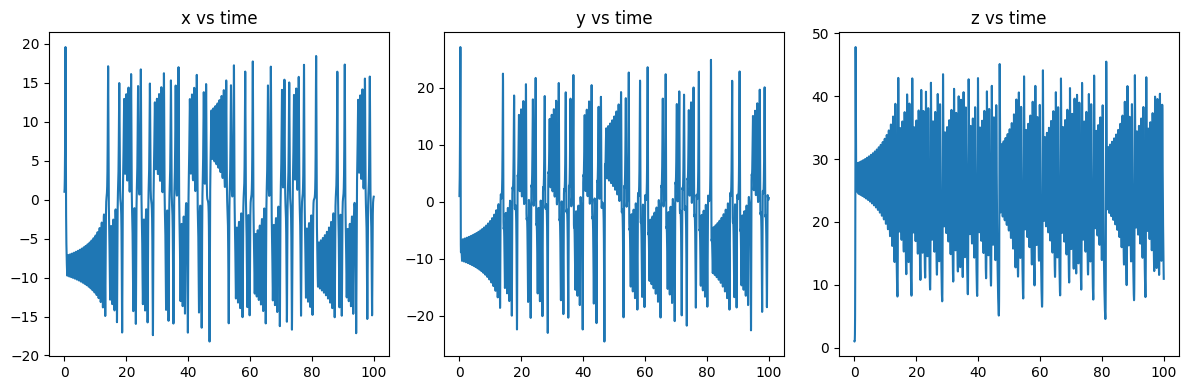

In [14]:
# Generate Lorenz data
t, x, y, z = generate_lorenz_data()

# Plot the data
plot_lorenz(t, x, y, z)

We now fully define each function that will be needed to run our reservoir. For this first step, we will keep everything very simple. We will use an Erdos Reyni network to create our reseroir and Win matrix. The dynamics of the reservior will be governed by
$$\frac{d\vec{r}_i}{dt} = -r_i + \tanh\left(\sum_j W_{ij} r_j + \sum_j W^{\text{in}}_{ij} u_j(t)\right)$$

Or in the standard leakage rate form:

$$\vec{r}(t+1) = (1-a)\,\vec{r}(t) + a\,\tanh\!\left(W\,\vec{r}(t) + W^{\text{in}}\,\vec{u}(t)\right)$$

To keep the training procedure as simple as possible, we did not use any extra bias term or augmented feature vector. Instead, after a washout period, we simply stored pairs of the form $$ (r_i , u_{i+1})$$
Meaning that the reservior state at time i was used to predict the Lorentz state at the next time step. The matrix $W_{out}$ was trained via ridge regression to optimise $$u(t+1)= W_{out}r(t)$$

Aditionally, the data was not normalised to keep everything simple. 

In [ ]:
# Reservoir system functions

#creates a matrix W of size (row, col) with a connection probability p and average strength J
def W_create(row, col, p, J):
    k = p * row
    strength = J / k
    random_probs = np.random.rand(row, col)
    adjacency = (random_probs < p).astype(float)
    signs = np.random.choice([-1, 1], size=(row, col))#weights can be positive or negative
    return adjacency * signs * strength

#defines the reservoir step function, which updates the reservoir state x based on the current state, the reservoir weights W, the input weights Win, the input u, and the leak rate
def Res_step(x, W, Win, u, leak_rate):
    return x * (1 - leak_rate) + leak_rate * np.tanh(W @ x + Win @ u)

#collects the reservoir states and corresponding target outputs after a defined washout period, which are used to train the output weights Wout
def collect_states(W, Win, train_len, washout_len, U):
    r = np.zeros(W.shape[0])
    stored_states = []
    for i in range(train_len):
        u = U[i]
        r = Res_step(r, W, Win, u, leak_rate=0.3)
        if i >= washout_len:
            stored_states.append((r.copy(), U[i + 1].copy()))
    return stored_states

#trains the output weights Wout using ridge regression on the collected reservoir states and target outputs
def train_Wout(states, reg=1e-6):
    R = np.vstack([r for r, _ in states])
    U = np.vstack([u for _, u in states])
    return np.linalg.solve(R.T @ R + reg * np.eye(R.shape[1]), R.T @ U).T
#-----training part done, now we will generate predictions-----

#defines a function to perform a single reservoir step in self-sustained mode, where the predicted output is fed back as input to the reservoir
def Res_step_self_sustained(r, W, Win, Wout, leak_rate=0.3):
    u_pred = Wout @ r
    r_next = r * (1 - leak_rate) + leak_rate * np.tanh(W @ r + Win @ u_pred)
    return r_next, u_pred

#generates predictions for the entire sequence by first using the teacher forcing method for a specified number of steps (teacher_len) and then switching to self-sustained mode for the remaining steps
def generate_predictions_whole(W, Win, Wout, U, teacher_len, leak_rate=0.3):
    r = np.zeros(W.shape[0])
    predictions = []
    for i in range(teacher_len):
        r = Res_step(r, W, Win, U[i], leak_rate)
        predictions.append(U[i])
    for _ in range(len(U) - teacher_len):
        r, u_pred = Res_step_self_sustained(r, W, Win, Wout, leak_rate)
        predictions.append(u_pred)
    return np.vstack(predictions)

Now that the reservior training and running are complete, we create a space to select all the necessary hyperperamaters and plot the results.

Not that for an Erdos Reyni netowrk the critical value of J is found at approximatley $$J_{critical} = \sqrt{pN}$$

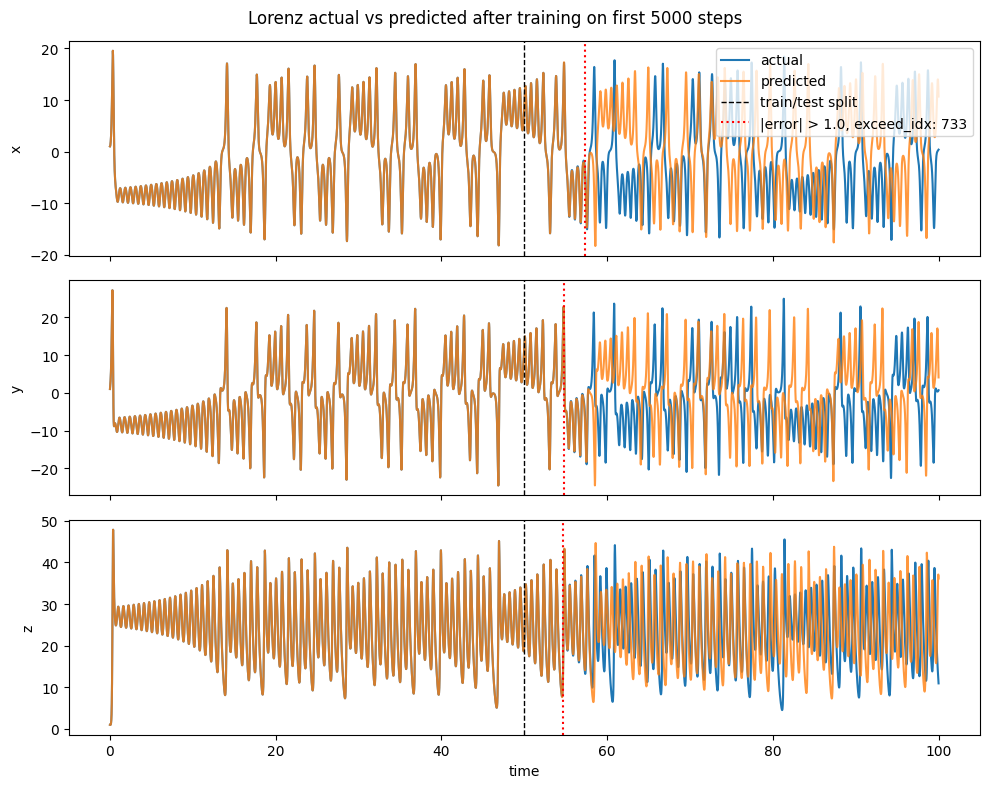

In [63]:
# Parameter setup and plotting

n_reservoir = 300
input_dim = 3
reservoir_density = 0.1
weight_scale = 4
leak_rate = 0.3

dt = 0.01
t_max = 100
train_len = 5000
washout_len = 1000

#creating the W and Win matrices
W = W_create(row=n_reservoir, col=n_reservoir, p=reservoir_density, J=weight_scale)
Win = W_create(row=n_reservoir, col=input_dim, p=0.5, J=weight_scale)

#generate the lorenz time series
t, x, y, z = generate_lorenz_data(dt=dt, t_max=t_max)
U = np.column_stack((x, y, z))

#collect states and train Wout
states = collect_states(W, Win, train_len, washout_len, U)
Wout = train_Wout(states)

#generate predictions and plot results
predicted = generate_predictions_whole(W, Win, Wout, U, train_len, leak_rate=leak_rate)
actual = U
time_pred = t

delta = 1.0  # choose your error threshold

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
labels = ['x', 'y', 'z']

# Plot actual vs predicted and mark where training stops and where the error exceeds the threshold
for j, ax in enumerate(axes):
    ax.plot(time_pred, actual[:, j], label='actual', color='tab:blue')
    ax.plot(time_pred, predicted[:, j], label='predicted', color='tab:orange', alpha=0.8)

    ax.axvline(time_pred[train_len], color='k', linestyle='--', linewidth=1, label='train/test split' if j == 0 else None)

    post_train_error = np.abs(actual[train_len:, j] - predicted[train_len:, j])
    exceed_idx = np.where(post_train_error > delta)[0]

    if len(exceed_idx) > 0:
        first_bad_idx = train_len + exceed_idx[0]
        ax.axvline(
            time_pred[first_bad_idx],
            color='red',
            linestyle=':',
            linewidth=1.5,
            label=f'|error| > {delta}, exceed_idx: {exceed_idx[0]}' if j == 0 else None
        )

    ax.set_ylabel(labels[j])

    if j == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel('time')
fig.suptitle('Lorenz actual vs predicted after training on first 5000 steps')
plt.tight_layout()
plt.show()


The real predicitons start after the dashed line at t=50, and continue for a while before diverging but still keeping simialr dynamics, which is a known porperty of reservoir computing. 

Here we try to see if there are any improvements if instead of using ridge regression on r(t) and u(t+1) we use the feature vector [1, r(t), u(t)] instead of simply r(t) which is typically known to improve prediction results in reservior computing.    

In [56]:
def collect_states_feature_vec(W, Win, train_len, washout_len, U):
    r = np.zeros(W.shape[0])
    stored_states = []
    for i in range(train_len):
        u = U[i]
        r = Res_step(r, W, Win, u, leak_rate=0.3)
        if i >= washout_len:
            stored_states.append((1, r.copy(), U[i].copy(), U[i + 1].copy()))
    return stored_states

def train_Wout_feature_vec(states, reg=1e-6):
    R = np.vstack([np.concatenate(([num], r, u_1)) for num, r, u_1, _ in states])
    U = np.vstack([u_2 for _, _, _, u_2 in states])
    return np.linalg.solve(R.T @ R + reg * np.eye(R.shape[1]), R.T @ U).T

def Res_step_self_sustained_feature_vec(r, W, Win, Wout, u, leak_rate=0.3):
    u_pred = Wout @ (np.concatenate(([1], r, u)))
    r_next = r * (1 - leak_rate) + leak_rate * np.tanh(W @ r + Win @ u_pred)
    return r_next, u_pred

def generate_predictions_whole_feature_vec(W, Win, Wout, U, teacher_len, leak_rate=0.3):
    r = np.zeros(W.shape[0])
    predictions = []
    for i in range(teacher_len):
        r = Res_step(r, W, Win, U[i], leak_rate)
        predictions.append(U[i])
    for i in range(len(U) - teacher_len):
        r, u_pred = Res_step_self_sustained_feature_vec(r, W, Win, Wout, predictions[teacher_len + i -1], leak_rate)
        predictions.append(u_pred)
    return np.vstack(predictions)

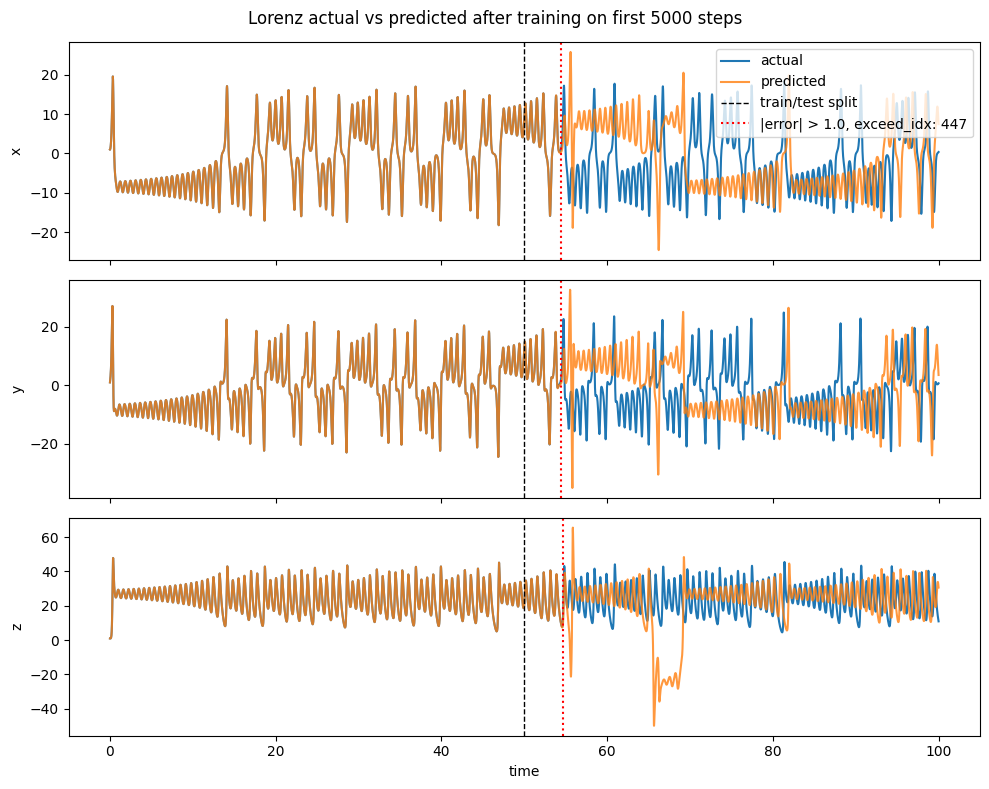

In [ ]:
# Parameter setup and plotting

n_reservoir = 300
input_dim = 3
reservoir_density = 0.1
weight_scale = 4
leak_rate = 0.3

dt = 0.01
t_max = 100
train_len = 5000
washout_len = 1000

#creating the W and Win matrices
#W = W_create(row=n_reservoir, col=n_reservoir, p=reservoir_density, J=weight_scale)
#Win = W_create(row=n_reservoir, col=input_dim, p=0.5, J=weight_scale)

#generate the lorenz time series
#t, x, y, z = generate_lorenz_data(dt=dt, t_max=t_max)
#U = np.column_stack((x, y, z))

#collect states and train Wout
states = collect_states_feature_vec(W, Win, train_len, washout_len, U)
Wout = train_Wout_feature_vec(states)

#generate predictions and plot results
predicted = generate_predictions_whole_feature_vec(W, Win, Wout, U, train_len, leak_rate=leak_rate)
actual = U
time_pred = t

delta = 1.0  # choose your error threshold

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
labels = ['x', 'y', 'z']

# Plot actual vs predicted and mark where training stops and where the error exceeds the threshold
for j, ax in enumerate(axes):
    ax.plot(time_pred, actual[:, j], label='actual', color='tab:blue')
    ax.plot(time_pred, predicted[:, j], label='predicted', color='tab:orange', alpha=0.8)

    ax.axvline(time_pred[train_len], color='k', linestyle='--', linewidth=1, label='train/test split' if j == 0 else None)

    post_train_error = np.abs(actual[train_len:, j] - predicted[train_len:, j])
    exceed_idx = np.where(post_train_error > delta)[0]

    if len(exceed_idx) > 0:
        first_bad_idx = train_len + exceed_idx[0]
        ax.axvline(
            time_pred[first_bad_idx],
            color='red',
            linestyle=':',
            linewidth=1.5,
            label=f'|error| > {delta}, exceed_idx: {exceed_idx[0]}' if j == 0 else None
        )

    ax.set_ylabel(labels[j])

    if j == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel('time')
fig.suptitle('Lorenz actual vs predicted after training on first 5000 steps')
plt.tight_layout()
plt.show()



Now we switch out the Erdos Renyi type W and Win matrix for a Normal Gaussain network to see if there are any noticable improvements.

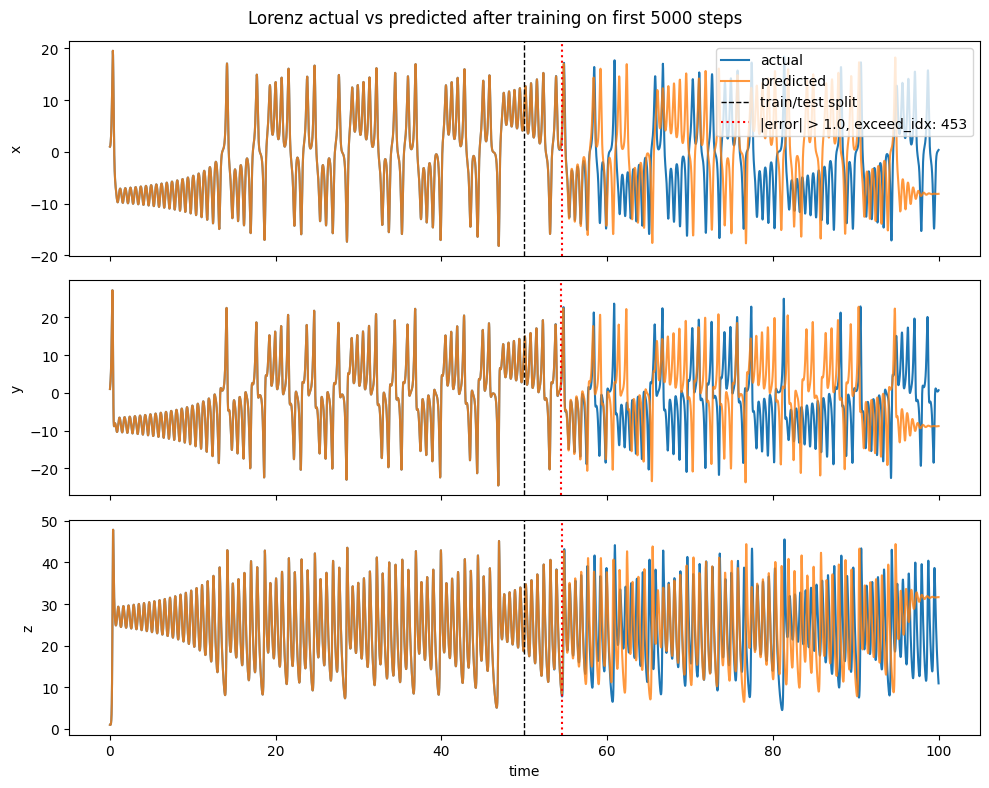

In [68]:
# Parameter setup and plotting

def W_create_gauss(row, col, J, mean=0.0):
    """
    Initializes the W matrix from a Gaussian distribution.
    The variance is J^2 / N, so the standard deviation is J / sqrt(N).
    """
    std_dev = J / np.sqrt(row)
    W = np.random.normal(loc=mean, scale=std_dev, size=(row, col))
    return W



n_reservoir = 300
input_dim = 3
reservoir_density = 0.1
weight_scale = 1
leak_rate = 0.3

dt = 0.01
t_max = 100
train_len = 5000
washout_len = 1000

#creating the W and Win matrices
W = W_create_gauss(row=n_reservoir, col=n_reservoir, J=weight_scale)
Win = W_create_gauss(row=n_reservoir, col=input_dim, J=weight_scale)

#generate the lorenz time series
t, x, y, z = generate_lorenz_data(dt=dt, t_max=t_max)
U = np.column_stack((x, y, z))

#collect states and train Wout
states = collect_states(W, Win, train_len, washout_len, U)
Wout = train_Wout(states)

#generate predictions and plot results
predicted = generate_predictions_whole(W, Win, Wout, U, train_len, leak_rate=leak_rate)
actual = U
time_pred = t

delta = 1.0  # choose your error threshold

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
labels = ['x', 'y', 'z']

# Plot actual vs predicted and mark where training stops and where the error exceeds the threshold
for j, ax in enumerate(axes):
    ax.plot(time_pred, actual[:, j], label='actual', color='tab:blue')
    ax.plot(time_pred, predicted[:, j], label='predicted', color='tab:orange', alpha=0.8)

    ax.axvline(time_pred[train_len], color='k', linestyle='--', linewidth=1, label='train/test split' if j == 0 else None)

    post_train_error = np.abs(actual[train_len:, j] - predicted[train_len:, j])
    exceed_idx = np.where(post_train_error > delta)[0]

    if len(exceed_idx) > 0:
        first_bad_idx = train_len + exceed_idx[0]
        ax.axvline(
            time_pred[first_bad_idx],
            color='red',
            linestyle=':',
            linewidth=1.5,
            label=f'|error| > {delta}, exceed_idx: {exceed_idx[0]}' if j == 0 else None
        )

    ax.set_ylabel(labels[j])

    if j == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel('time')
fig.suptitle('Lorenz actual vs predicted after training on first 5000 steps')
plt.tight_layout()
plt.show()